# Replication Consistency Analysis

Analyze answer variability across repeated runs on identical prompts.

**Key metrics:**
- **Exact-match rate**: fraction of prompts where all N runs gave the same `model_answer`
- **Majority-agree rate**: fraction where ≥ 3 of 5 runs agree on one answer
- **Answer CV** (coefficient of variation): for numeric answers, std / |mean| across runs
- **Accuracy spread**: difference between best-run and worst-run accuracy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PROJECT_ROOT = Path('/data/jane/convert/math_gender/conversion_test')
RESULTS_DIR = PROJECT_ROOT / '4_replication_test' / 'replication_results'

NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'claude-haiku-4-5', 'qwen3-235b-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'qwen-coder': 'Qwen3-Coder',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B ★',
    'claude-haiku-4-5': 'Claude-Haiku-4.5 ★',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

MODEL_COLORS = {
    'gpt-4o': '#1f77b4',
    'qwen-coder': '#ff7f0e',
    'llama-4': '#2ca02c',
    'gpt-5.2': '#d62728',
    'deepseek-v3.1': '#9467bd',
    'qwen3-235b-thinking': '#8c564b',
    'claude-haiku-4-5': '#e377c2',
    'gpt-oss-120b': '#7f7f7f',
}

CONDITION_DISPLAY = {
    'in_domain_with_guide': 'With Guide',
    'in_domain_no_guide': 'No Guide',
    'math_only': 'Math Only',
}

## 1. Load replication results

In [16]:
frames = []
for tsv in sorted(RESULTS_DIR.glob("*.tsv")):
    model_name = tsv.stem
    try:
        mdf = pd.read_csv(tsv, sep='\t', low_memory=False)
        mdf['model'] = model_name
        frames.append(mdf)
        done = mdf['raw_response'].notna() & ~mdf['raw_response'].astype(str).isin(['null','nan',''])
        print(f"  {model_name:25s}  {done.sum():>6,} / {len(mdf):>6,} rows complete")
    except Exception as e:
        print(f"  {model_name:25s}  ERROR: {e}")

df = pd.concat(frames, ignore_index=True)

# Clean up types
df['loss'] = pd.to_numeric(df['loss'], errors='coerce')
df['model_answer'] = df['model_answer'].astype(str).replace({'null': np.nan, 'nan': np.nan, 'None': np.nan})
df['is_correct'] = df['loss'] == 0
df['run_id'] = df['run_id'].astype(int)
df['prompt_idx'] = df['prompt_idx'].astype(int)

models_loaded = [m for m in ALL_MODELS if m in df['model'].unique()]
print(f"\nLoaded {len(df):,} total rows across {len(models_loaded)} models")
print(f"Prompts per model: {df.groupby('model')['prompt_idx'].nunique().to_dict()}")
print(f"Runs per prompt: {df.groupby(['model','prompt_idx']).size().mode().values}")

  claude-haiku-4-5            4,950 /  4,950 rows complete
  deepseek-v3.1               4,950 /  4,950 rows complete
  gpt-4o                      4,950 /  4,950 rows complete
  gpt-5.2                     4,950 /  4,950 rows complete
  gpt-oss-120b                4,950 /  4,950 rows complete
  llama-4                     4,950 /  4,950 rows complete
  qwen-coder                  4,950 /  4,950 rows complete
  qwen3-235b-thinking           500 /  4,950 rows complete

Loaded 39,600 total rows across 8 models
Prompts per model: {'claude-haiku-4-5': 990, 'deepseek-v3.1': 990, 'gpt-4o': 990, 'gpt-5.2': 990, 'gpt-oss-120b': 990, 'llama-4': 990, 'qwen-coder': 990, 'qwen3-235b-thinking': 990}
Runs per prompt: [5]


In [17]:
# Helper: compute consistency metrics for a group of (prompt_idx, model) runs
def consistency_metrics(group):
    """Given all runs for one prompt × model, return consistency stats."""
    answers = group['model_answer'].dropna()
    n_runs = len(group)
    n_valid = len(answers)

    # Exact match: all valid answers identical
    exact_match = (answers.nunique() == 1) if n_valid >= 2 else np.nan

    # Majority agree: most common answer appears in >= 60% of runs
    if n_valid >= 2:
        top_count = answers.value_counts().iloc[0]
        majority_agree = top_count >= (n_runs * 0.6)
        majority_frac = top_count / n_runs
    else:
        majority_agree = np.nan
        majority_frac = np.nan

    # Numeric CV: std / |mean| for numeric answers
    numeric_vals = pd.to_numeric(answers, errors='coerce').dropna()
    if len(numeric_vals) >= 2 and numeric_vals.mean() != 0:
        cv = numeric_vals.std() / abs(numeric_vals.mean())
    else:
        cv = np.nan

    # Accuracy: fraction of runs that were correct
    n_correct = group['is_correct'].sum()
    accuracy = n_correct / n_runs

    return pd.Series({
        'n_runs': n_runs,
        'n_valid': n_valid,
        'n_unique_answers': answers.nunique() if n_valid else 0,
        'exact_match': exact_match,
        'majority_agree': majority_agree,
        'majority_frac': majority_frac,
        'cv': cv,
        'accuracy': accuracy,
        'n_correct': n_correct,
        'domain': group['domain'].iloc[0],
        'condition': group['condition'].iloc[0],
    })

# Compute per prompt × model
prompt_stats = df.groupby(['model', 'prompt_idx']).apply(consistency_metrics).reset_index()
print(f"Computed consistency for {len(prompt_stats):,} prompt×model combinations")
prompt_stats.head()

Computed consistency for 7,920 prompt×model combinations


,model,prompt_idx,n_runs,n_valid,n_unique_answers,exact_match,majority_agree,majority_frac,cv,accuracy,n_correct,domain,condition
0,claude-haiku-4-5,0,5,5,1,True,True,1.0,0.0,0.0,0,bits_bytes,in_domain_with_guide
1,claude-haiku-4-5,1,5,5,1,True,True,1.0,0.0,1.0,5,bits_bytes,in_domain_with_guide
2,claude-haiku-4-5,2,5,5,1,True,True,1.0,0.0,1.0,5,bits_bytes,in_domain_with_guide
3,claude-haiku-4-5,3,5,5,1,True,True,1.0,0.0,1.0,5,bits_bytes,in_domain_with_guide
4,claude-haiku-4-5,4,5,5,1,True,True,1.0,0.0,1.0,5,bits_bytes,in_domain_with_guide


## 2. Consistency by Model

In [18]:
# Summary table by model
model_summary = prompt_stats.groupby('model').agg(
    n_prompts=('prompt_idx', 'nunique'),
    exact_match_rate=('exact_match', 'mean'),
    majority_agree_rate=('majority_agree', 'mean'),
    mean_majority_frac=('majority_frac', 'mean'),
    median_cv=('cv', 'median'),
    mean_accuracy=('accuracy', 'mean'),
    mean_unique_answers=('n_unique_answers', 'mean'),
).reindex([m for m in ALL_MODELS if m in prompt_stats['model'].unique()])

model_summary['display'] = model_summary.index.map(lambda m: MODEL_DISPLAY.get(m, m))

print("=== Consistency Summary by Model ===\n")
display_cols = model_summary[['display', 'n_prompts', 'exact_match_rate', 'majority_agree_rate',
                               'mean_majority_frac', 'median_cv', 'mean_accuracy', 'mean_unique_answers']].copy()
display_cols.columns = ['Model', 'Prompts', 'Exact Match %', 'Majority Agree %',
                        'Mean Majority Frac', 'Median CV', 'Mean Accuracy', 'Mean Unique Answers']
for col in ['Exact Match %', 'Majority Agree %', 'Mean Accuracy']:
    display_cols[col] = (pd.to_numeric(display_cols[col], errors='coerce') * 100).round(1)
display_cols['Mean Majority Frac'] = (pd.to_numeric(display_cols['Mean Majority Frac'], errors='coerce') * 100).round(1)
display_cols['Median CV'] = pd.to_numeric(display_cols['Median CV'], errors='coerce').round(4)
display_cols['Mean Unique Answers'] = display_cols['Mean Unique Answers'].round(2)
print(display_cols.to_string(index=False))

=== Consistency Summary by Model ===

              Model  Prompts  Exact Match %  Majority Agree %  Mean Majority Frac  Median CV  Mean Accuracy  Mean Unique Answers
             GPT-4o      990           80.7               0.1                93.6        0.0           72.4                 1.24
        Qwen3-Coder      990           88.5               0.1                96.1        0.0           68.8                 1.12
   Llama-4-Maverick      990           74.8               0.1                89.8        0.0           72.7                 1.42
       GPT-OSS-120B      990           88.4              75.0                91.8        0.0           68.6                 1.12
          GPT-5.2 ★      990           73.3               0.1                86.4        0.0           89.0                 1.60
    DeepSeek-V3.1 ★      990           51.1               0.1                75.7        0.0           73.6                 2.10
 Claude-Haiku-4.5 ★      990           53.9               0

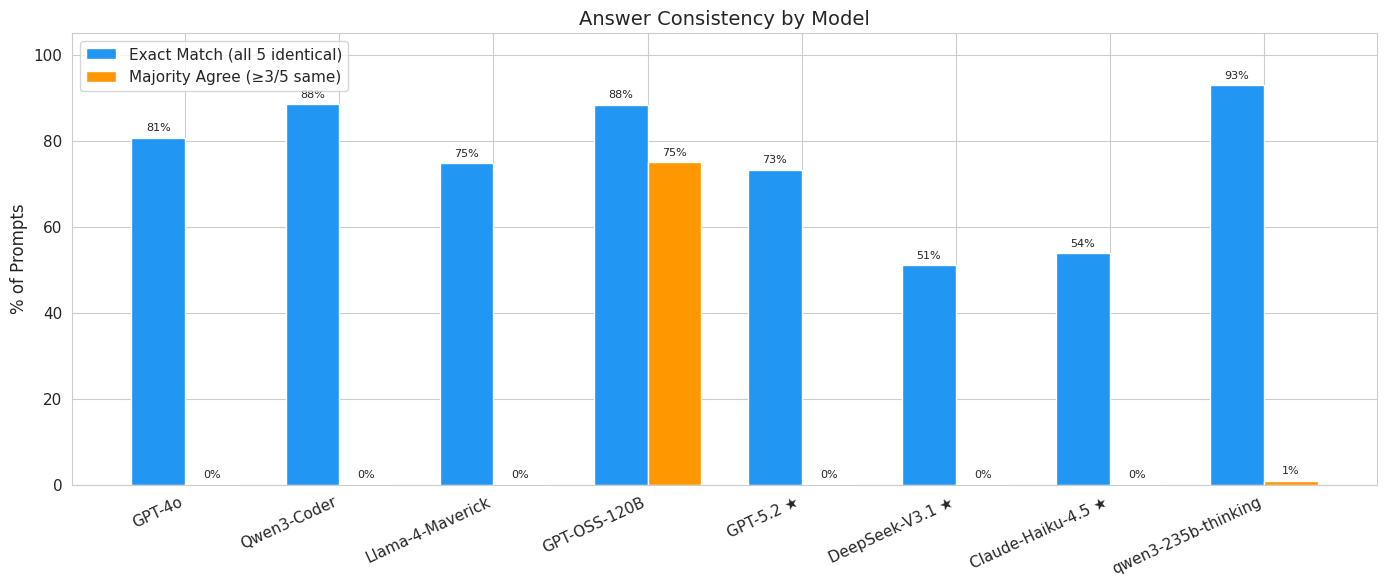

In [19]:
# Bar chart: exact match rate and majority agree rate by model
ordered = [m for m in ALL_MODELS if m in prompt_stats['model'].unique()]
labels = [MODEL_DISPLAY.get(m, m) for m in ordered]

exact = [prompt_stats[prompt_stats['model']==m]['exact_match'].mean()*100 for m in ordered]
majority = [prompt_stats[prompt_stats['model']==m]['majority_agree'].mean()*100 for m in ordered]

x = np.arange(len(ordered))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, exact, w, label='Exact Match (all 5 identical)', color='#2196F3')
ax.bar(x + w/2, majority, w, label='Majority Agree (≥3/5 same)', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylabel('% of Prompts')
ax.set_ylim(0, 105)
ax.set_title('Answer Consistency by Model')
ax.legend()
for i, (e, m) in enumerate(zip(exact, majority)):
    ax.text(i - w/2, e + 1, f'{e:.0f}%', ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, m + 1, f'{m:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2822988/400979737.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True, showmeans=True)


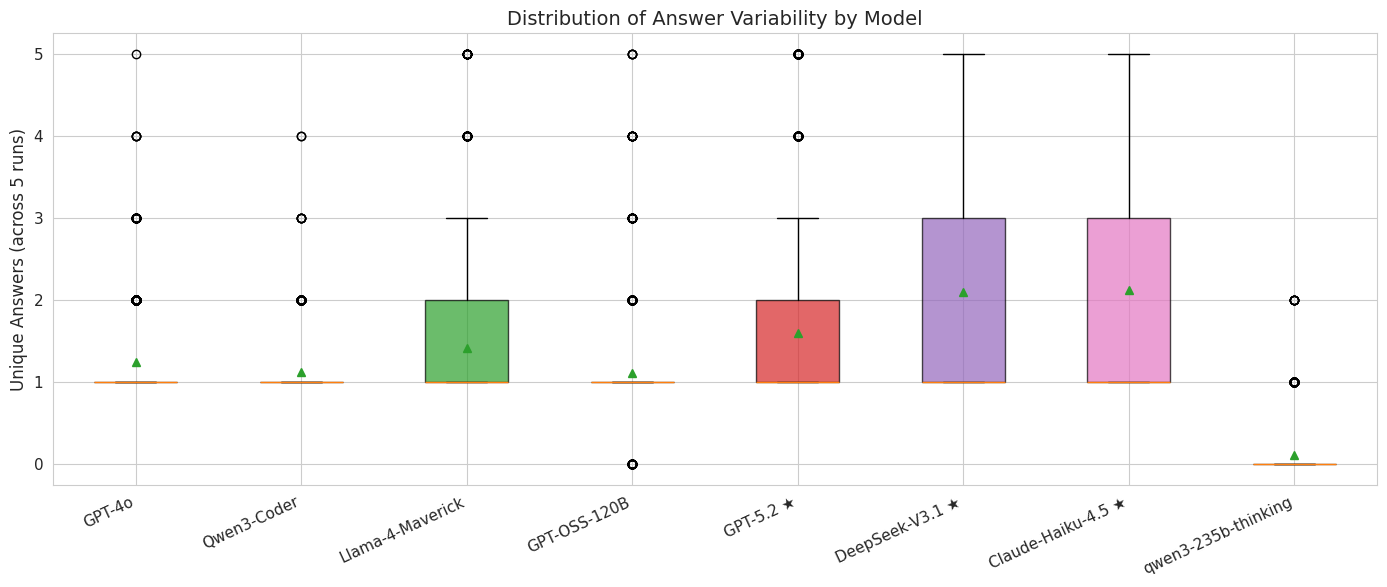

In [20]:
# Distribution of unique answers per prompt, by model
fig, ax = plt.subplots(figsize=(14, 6))
data_for_box = []
for m in ordered:
    vals = prompt_stats[prompt_stats['model'] == m]['n_unique_answers']
    data_for_box.append(vals)
bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True, showmeans=True)
for patch, m in zip(bp['boxes'], ordered):
    patch.set_facecolor(MODEL_COLORS.get(m, '#cccccc'))
    patch.set_alpha(0.7)
ax.set_ylabel('Unique Answers (across 5 runs)')
ax.set_title('Distribution of Answer Variability by Model')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

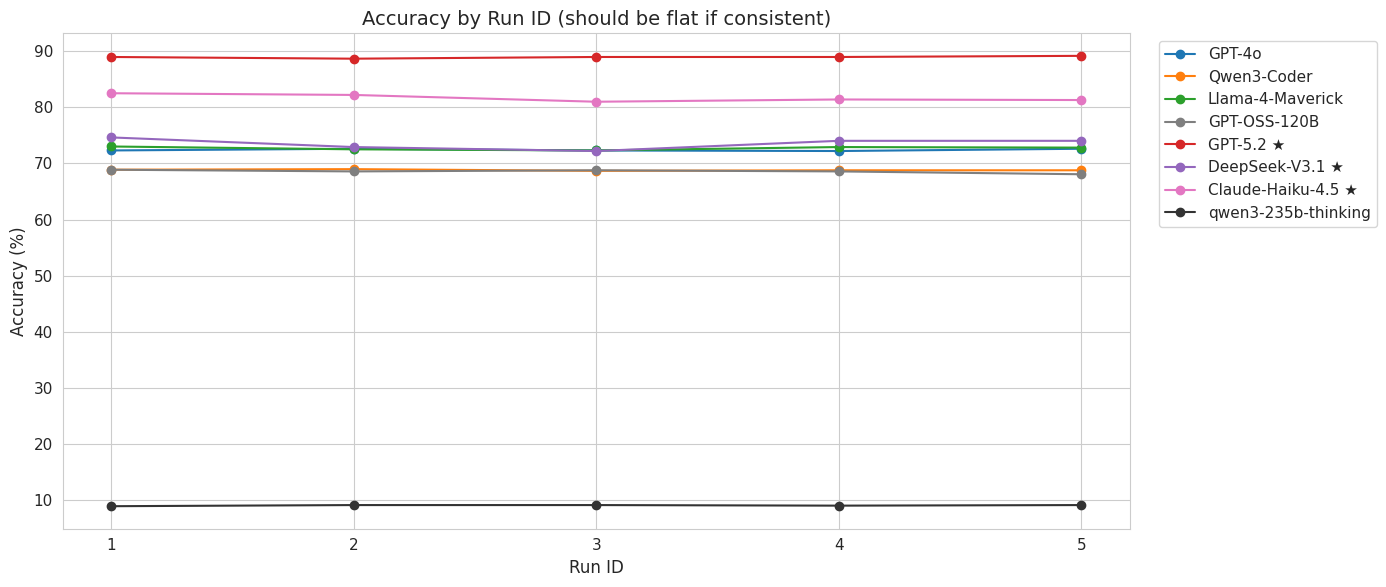

Accuracy spread across runs (percentage points):
                     spread_pp
GPT-4o                    0.40
Qwen3-Coder               0.30
Llama-4-Maverick          0.71
GPT-OSS-120B              0.81
GPT-5.2 ★                 0.51
DeepSeek-V3.1 ★           2.42
Claude-Haiku-4.5 ★        1.52
qwen3-235b-thinking       0.20


In [21]:
# Per-run accuracy by model: does accuracy vary across the 5 runs?
run_acc = df.groupby(['model', 'run_id'])['is_correct'].mean().reset_index()
run_acc.columns = ['model', 'run_id', 'accuracy']

fig, ax = plt.subplots(figsize=(14, 6))
for m in ordered:
    mdata = run_acc[run_acc['model'] == m]
    ax.plot(mdata['run_id'], mdata['accuracy'] * 100, 'o-',
            label=MODEL_DISPLAY.get(m, m), color=MODEL_COLORS.get(m, '#333'))
ax.set_xlabel('Run ID')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Run ID (should be flat if consistent)')
ax.set_xticks(range(1, df['run_id'].max() + 1))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print accuracy spread (max - min across runs)
spread = run_acc.groupby('model')['accuracy'].agg(['min','max'])
spread['spread_pp'] = ((spread['max'] - spread['min']) * 100).round(2)
spread = spread.reindex([m for m in ordered])
spread.index = [MODEL_DISPLAY.get(m, m) for m in spread.index]
print("Accuracy spread across runs (percentage points):")
print(spread[['spread_pp']].to_string())

## 3. Consistency by Condition

In [22]:
# Consistency by condition (across all models)
cond_summary = prompt_stats.groupby('condition').agg(
    n_prompts=('prompt_idx', 'count'),
    exact_match_rate=('exact_match', 'mean'),
    majority_agree_rate=('majority_agree', 'mean'),
    median_cv=('cv', 'median'),
    mean_accuracy=('accuracy', 'mean'),
    mean_unique=('n_unique_answers', 'mean'),
)

print("=== Consistency by Condition (all models pooled) ===\n")
cond_display = cond_summary.copy()
cond_display.index = cond_display.index.map(lambda c: CONDITION_DISPLAY.get(c, c))
for col in ['exact_match_rate', 'majority_agree_rate', 'mean_accuracy']:
    cond_display[col] = (pd.to_numeric(cond_display[col], errors='coerce') * 100).round(1)
cond_display['median_cv'] = pd.to_numeric(cond_display['median_cv'], errors='coerce').round(4)
cond_display['mean_unique'] = pd.to_numeric(cond_display['mean_unique'], errors='coerce').round(2)
cond_display.columns = ['N', 'Exact Match %', 'Majority %', 'Median CV', 'Accuracy %', 'Mean Unique']
print(cond_display.to_string())

=== Consistency by Condition (all models pooled) ===

               N  Exact Match %  Majority %  Median CV  Accuracy %  Mean Unique
condition                                                                      
No Guide    2640           67.9        37.9        0.0        59.9         1.42
With Guide  2640           70.4        37.3        0.0        69.2         1.45
Math Only   2640           81.0        40.8        0.0        71.8         1.20


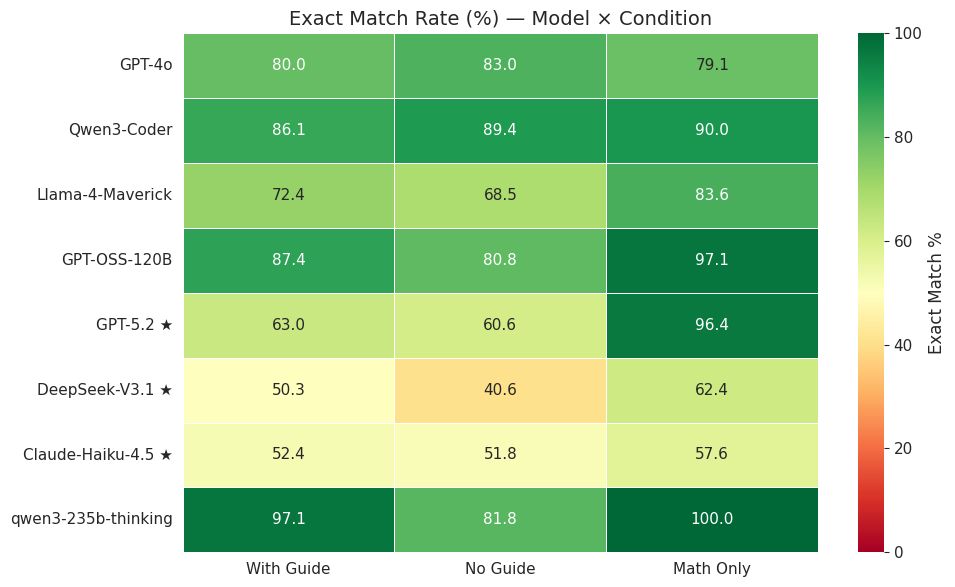

In [23]:
# Exact match rate: model × condition heatmap
pivot = prompt_stats.groupby(['model', 'condition'])['exact_match'].mean().unstack(fill_value=0) * 100
pivot = pivot.reindex(index=[m for m in ordered if m in pivot.index])
pivot = pivot.reindex(columns=['in_domain_with_guide', 'in_domain_no_guide', 'math_only'])
pivot.columns = [CONDITION_DISPLAY.get(c, c) for c in pivot.columns]
pivot.index = [MODEL_DISPLAY.get(m, m) for m in pivot.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot.astype(float), annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Exact Match %'})
ax.set_title('Exact Match Rate (%) — Model × Condition')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

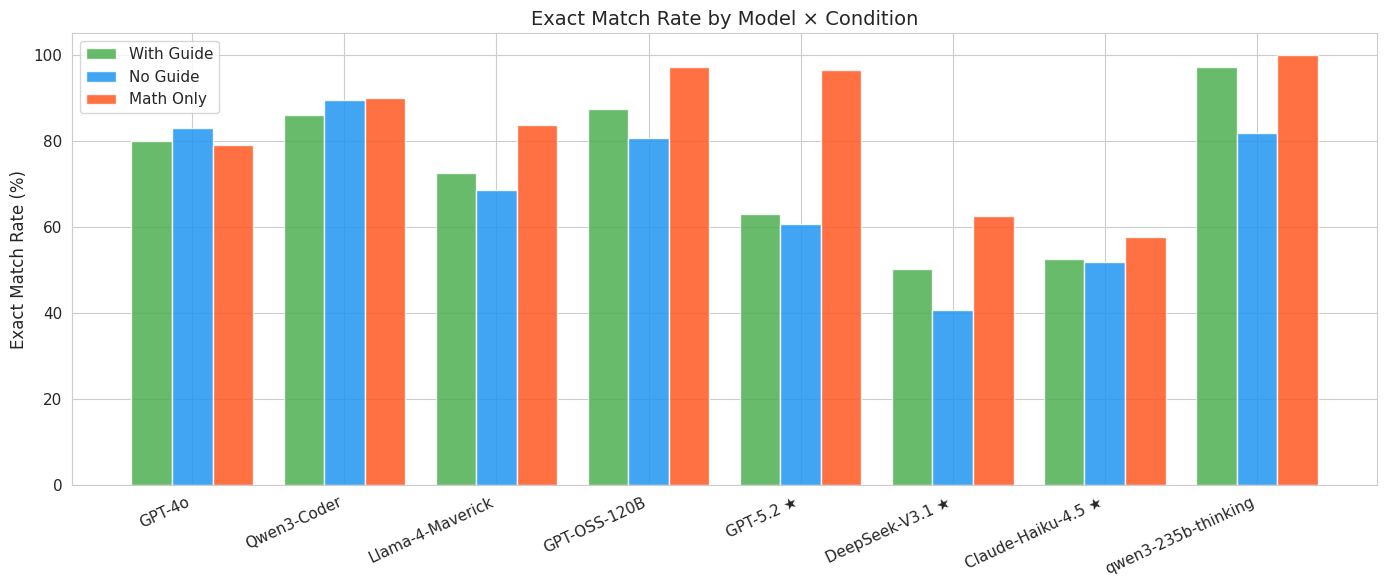

In [24]:
# Grouped bar: exact match by model, grouped by condition
conditions = ['in_domain_with_guide', 'in_domain_no_guide', 'math_only']
cond_labels = [CONDITION_DISPLAY[c] for c in conditions]

x = np.arange(len(ordered))
n_cond = len(conditions)
w = 0.8 / n_cond
cond_colors = ['#4CAF50', '#2196F3', '#FF5722']

fig, ax = plt.subplots(figsize=(14, 6))
for ci, (cond, clabel) in enumerate(zip(conditions, cond_labels)):
    vals = []
    for m in ordered:
        sub = prompt_stats[(prompt_stats['model'] == m) & (prompt_stats['condition'] == cond)]
        vals.append(sub['exact_match'].mean() * 100 if len(sub) else 0)
    offset = (ci - n_cond / 2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=clabel, color=cond_colors[ci], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY.get(m, m) for m in ordered], rotation=25, ha='right')
ax.set_ylabel('Exact Match Rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Exact Match Rate by Model × Condition')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Consistency by Domain

In [25]:
# Consistency summary by domain (all models pooled)
dom_summary = prompt_stats.groupby('domain').agg(
    n=('prompt_idx', 'count'),
    exact_match_rate=('exact_match', 'mean'),
    majority_agree_rate=('majority_agree', 'mean'),
    median_cv=('cv', 'median'),
    mean_accuracy=('accuracy', 'mean'),
    mean_unique=('n_unique_answers', 'mean'),
).sort_values('exact_match_rate')

print("=== Consistency by Domain (all models pooled) ===\n")
dom_display = dom_summary.copy()
for col in ['exact_match_rate', 'majority_agree_rate', 'mean_accuracy']:
    dom_display[col] = (pd.to_numeric(dom_display[col], errors='coerce') * 100).round(1)
dom_display['median_cv'] = pd.to_numeric(dom_display['median_cv'], errors='coerce').round(4)
dom_display['mean_unique'] = pd.to_numeric(dom_display['mean_unique'], errors='coerce').round(2)
dom_display.columns = ['N', 'Exact Match %', 'Majority %', 'Median CV', 'Accuracy %', 'Mean Unique']
print(dom_display.to_string())

=== Consistency by Domain (all models pooled) ===

                      N  Exact Match %  Majority %  Median CV  Accuracy %  Mean Unique
domain                                                                                
currency            792           43.4        32.0        0.0        46.0         2.05
density             792           64.8        38.4        0.0        63.5         1.57
moles_to_particles  792           67.8        35.5        0.0        11.3         1.35
volume              792           69.2        38.9        0.0        76.8         1.42
speed               792           71.8        32.4        0.0        85.2         1.34
energy              792           73.2        39.5        0.0        75.1         1.37
timezone            792           77.6         0.1        NaN        77.3         1.11
temperature         792           84.3         0.1        0.0        78.3         1.11
cooking             792           86.1        32.0        0.0        82.0      

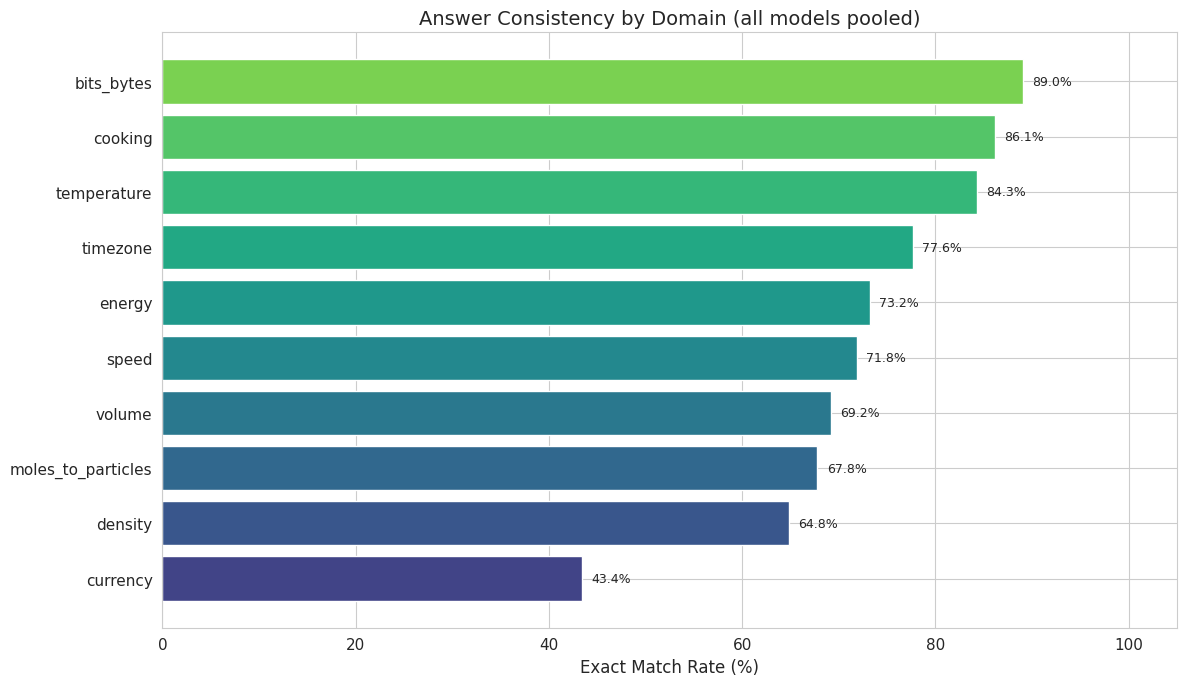

In [26]:
# Horizontal bar chart: exact match rate by domain
domains_sorted = dom_summary.index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(domains_sorted)))
ax.barh(range(len(domains_sorted)),
        [dom_summary.loc[d, 'exact_match_rate'] * 100 for d in domains_sorted],
        color=colors)
ax.set_yticks(range(len(domains_sorted)))
ax.set_yticklabels(domains_sorted)
ax.set_xlabel('Exact Match Rate (%)')
ax.set_title('Answer Consistency by Domain (all models pooled)')
ax.set_xlim(0, 105)
for i, d in enumerate(domains_sorted):
    v = dom_summary.loc[d, 'exact_match_rate'] * 100
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()